In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import os

## Вспомогательная функция для проверки стационарности

In [50]:
def test_stationarity(timeseries):
    """
    Возвращает p-value теста Дики-Фуллера
    """
    return adfuller(timeseries.dropna(), autolag='AIC', result_object=True).pvalue


def find_best_diff(timeseries, end=30):
    """
    Находит лучшее значение дифференцирования
    """
    # Начальные значения
    best_diff = None
    p_value = test_stationarity(timeseries)

    # Поиск оптимального перебором лага (смещения)
    for diff_val in range(1, end):
        new_p_value = test_stationarity(timeseries.diff(diff_val))
        if new_p_value < p_value:
            p_value = new_p_value
            best_diff = diff_val

    return best_diff

In [51]:
def test_stationarity_report(timeseries, title=""):
    print(f'--- Тест Дики-Фуллера для: {title} ---')
    dftest = adfuller(timeseries.dropna(), autolag='AIC', result_object=False)
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)

    if dfoutput['p-value'] < 0.05:
        print("Результат: Ряд СТАЦИОНАРЕН (p < 0.05)")
    else:
        print("Результат: Ряд НЕСТАЦИОНАРЕН (p >= 0.05)")
    print('\n')

In [52]:
def plot_series(original, transformed=None, title=""):
    """
    Выводит один или два графика. Предназначен для вывода исходного ряда и измененного.
    """
    # Определение количества колонок
    n_cols = 1 if transformed is None else 2

    fig, axes = plt.subplots(1, ncols=n_cols, figsize=(15, 4), squeeze=False)

    axes[0, 0].plot(original)
    axes[0, 0].set_title(f"{title} (Исходный)")
    axes[0, 0].grid(True)

    if transformed is not None:
        axes[0, 1].plot(transformed, marker="o")
        axes[0, 1].set_title(f"{title} (Измененный)")
        axes[0, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [53]:
def plot_my_acf(data, lags=None, title="Автокорреляционная функция (ACF)"):
    """Строит график автокорреляционной функции (ACF) для временного ряда.

    Parameters:
    data (array-like): Временной ряд (список, массив numpy или Series pandas).
    lags (int, optional): Количество лагов для расчета. Если None, рассчитывается
    автоматически.
    title (str): Заголовок графика.
    """
    # Преобразуем данные в одномерный массив numpy, очищая от NaN
    cleaned_data = np.asarray(data)
    cleaned_data = cleaned_data[~np.isnan(cleaned_data)]

    # Настройка стиля графика
    fig, ax = plt.subplots(figsize=(10, 5))

    # Построение ACF с помощью statsmodels
    plot_acf(cleaned_data, lags=lags, ax=ax, alpha=0.05)

    # Оформление
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Лаг (Смещение)", fontsize=12)
    ax.set_ylabel("Коэффициент автокорреляции", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


## 1. Monthly Sales of Company X

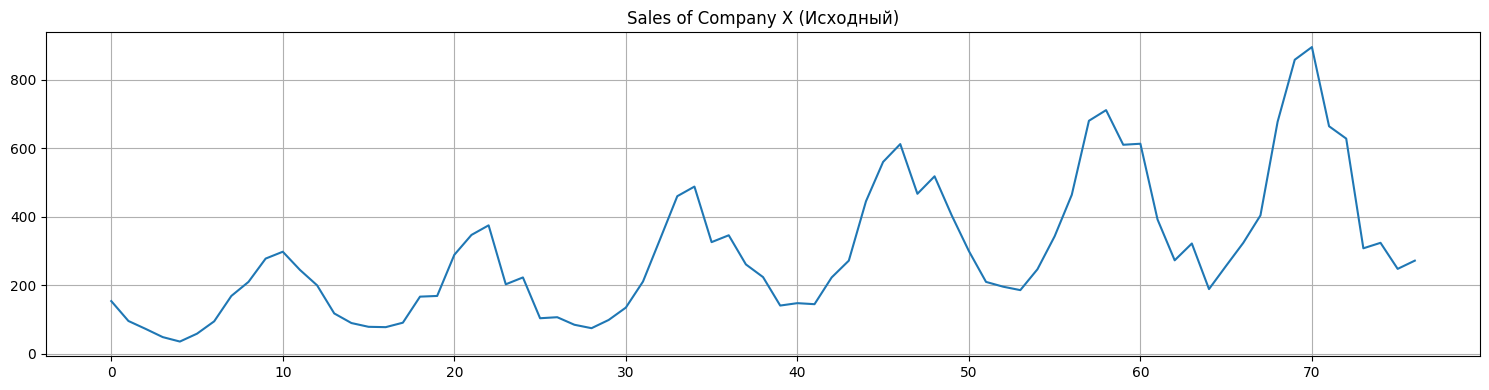

--- Тест Дики-Фуллера для: Sales of Company X ---
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64
Результат: Ряд НЕСТАЦИОНАРЕН (p >= 0.05)




In [54]:
path1 = 'monthly-sales-of-company-x-jan-6.csv'
df1 = pd.read_csv(path1)
val1 = df1.iloc[:, 1]

plot_series(val1, title="Sales of Company X")

test_stationarity_report(val1, "Sales of Company X")

Заметна увеличивающаяся дисперсия, что выражается в амплитуде колебаний. Для нормализации дисперсии прологарифмируем ряд.

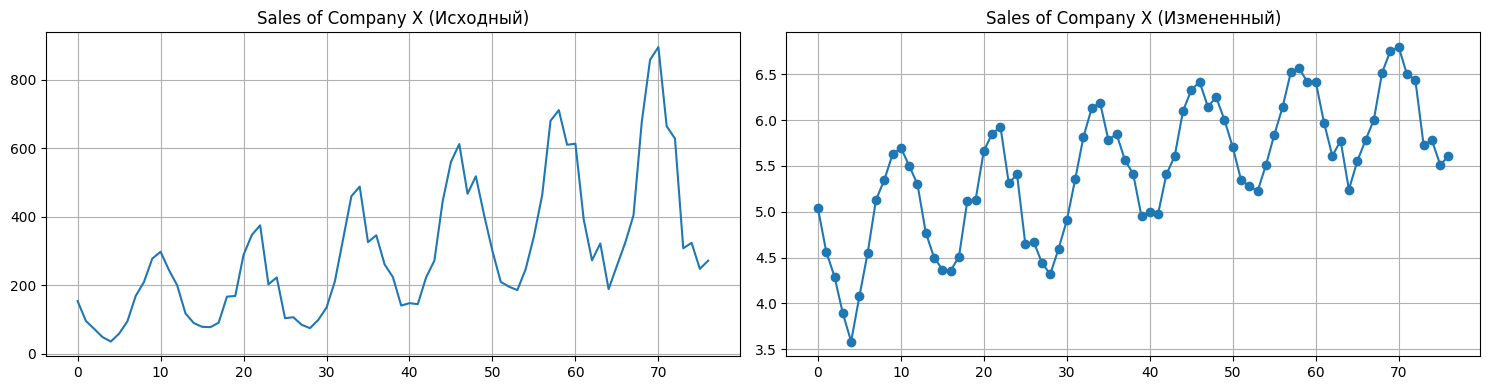

In [55]:
val1_log = np.log(val1)

plot_series(val1, val1_log, title="Sales of Company X")

Построим коррелограмму:

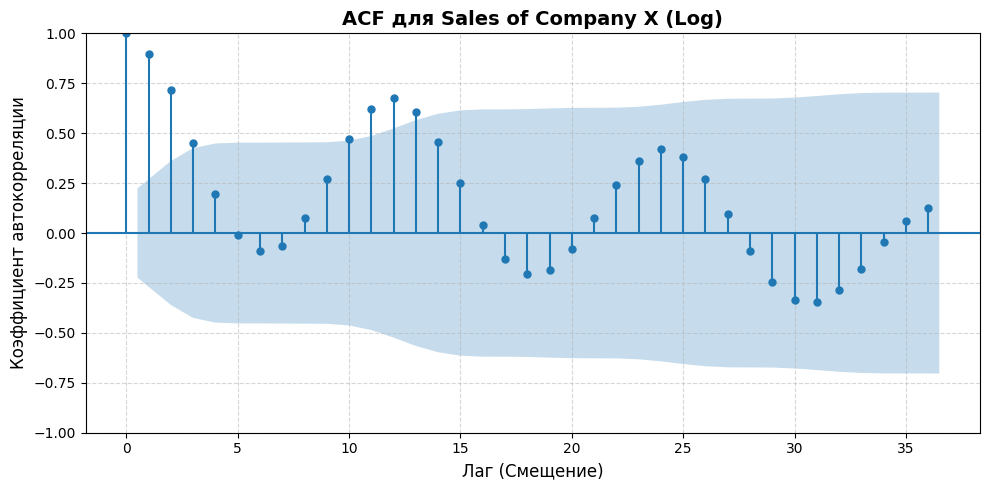

In [82]:
plot_my_acf(val1_log, lags=36, title="ACF для Sales of Company X (Log)")

Хорошо видны пики автокорреляций для смещения кратного 12. Продифференцируем ряд со сдвигом 12:

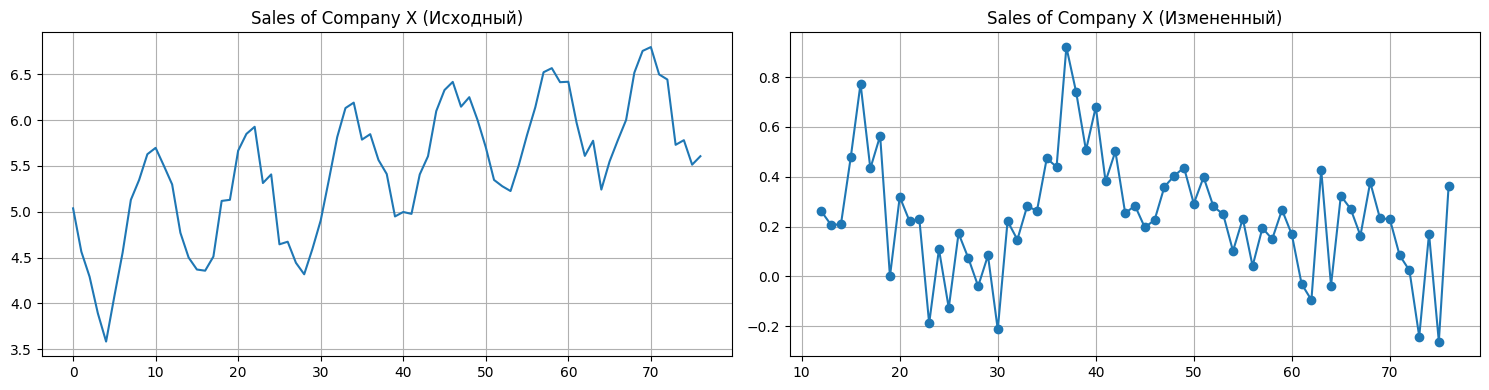

--- Тест Дики-Фуллера для: Sales of Company X ---
Test Statistic                 -2.385128
p-value                         0.145978
#Lags Used                     11.000000
Number of Observations Used    53.000000
Critical Value (1%)            -3.560242
Critical Value (5%)            -2.917850
Critical Value (10%)           -2.596796
dtype: float64
Результат: Ряд НЕСТАЦИОНАРЕН (p >= 0.05)




In [57]:
val1_log_12 = val1_log.diff(12)

plot_series(val1_log, val1_log_12, title="Sales of Company X")

test_stationarity_report(val1_log_12, "Sales of Company X")

Визуально в измененном ряде явно выраженной периодичности не наблюдается. Однако, тест Дики-Фуллера говорит, что стационарности мы еще не достигли.

Основываясь на результатах теста Дики-Фуллера найдем оптимальный лаг и проведем повторное дифференцирование:

При лаге деффиринцирования 4 значение p-value минимально


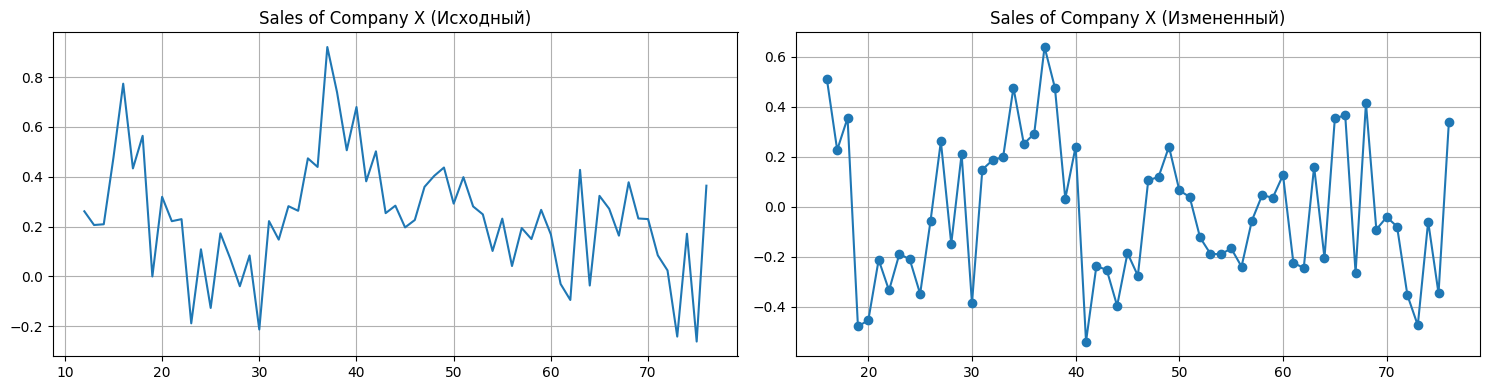

--- Тест Дики-Фуллера для: Sales of Company X ---
Test Statistic                 -4.065956
p-value                         0.001102
#Lags Used                     11.000000
Number of Observations Used    49.000000
Critical Value (1%)            -3.571472
Critical Value (5%)            -2.922629
Critical Value (10%)           -2.599336
dtype: float64
Результат: Ряд СТАЦИОНАРЕН (p < 0.05)




In [58]:
best_diff = find_best_diff(val1_log_12)

if best_diff is None:
    print("Значение не найдено (любое деффиринцирование увеличивает p-value)")
else:
    print(f"При лаге деффиринцирования {best_diff} значение p-value минимально")
    plot_series(val1_log_12, val1_log_12.diff(best_diff), title="Sales of Company X")

    test_stationarity_report(val1_log_12.diff(best_diff), "Sales of Company X")

Визуально в измененном ряде явно выраженной периодичности не наблюдается.

Тест Дики-Фуллера показывает, что мы достигли стационарности.

Выведем коррелограмму:

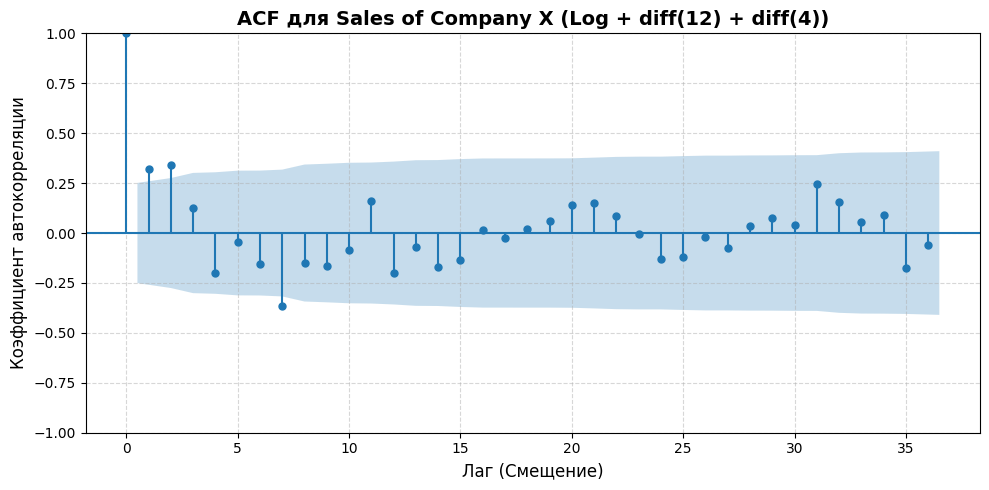

In [59]:
plot_my_acf(val1_log_12.diff(best_diff), lags=36, title="ACF для Sales of Company X (Log + diff(12) + diff(4))")

## 2. Monthly Boston Armed Robberies

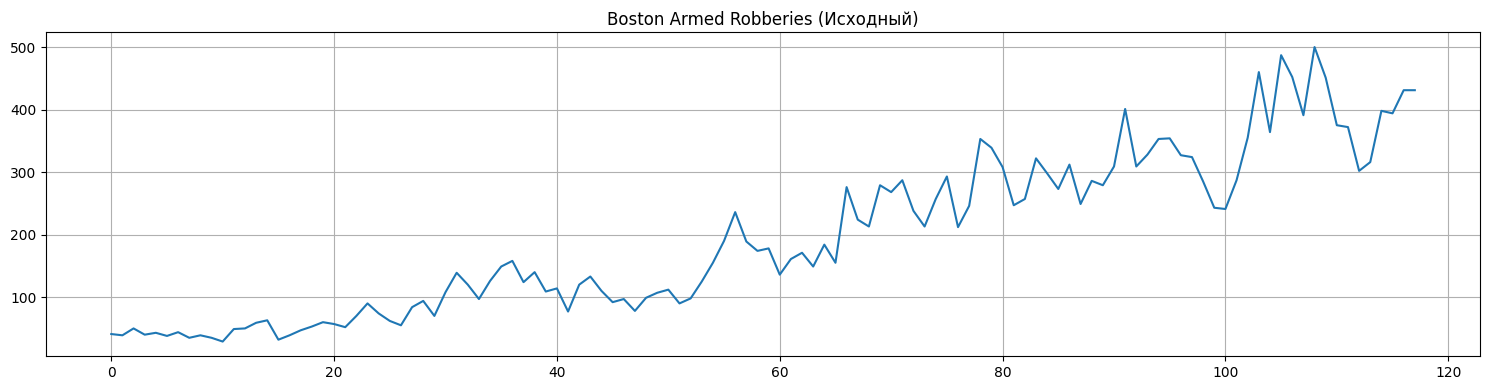

--- Тест Дики-Фуллера для: Boston Armed Robberies ---
Test Statistic                   1.001102
p-value                          0.994278
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64
Результат: Ряд НЕСТАЦИОНАРЕН (p >= 0.05)




In [60]:
path2 = 'monthly-boston-armed-robberies-j.csv'
df2 = pd.read_csv(path2)
val2 = df2.iloc[:, 1]

plot_series(val2, title="Boston Armed Robberies")

test_stationarity_report(val2, "Boston Armed Robberies")

Заметна увеличивающаяся дисперсия, что выражается в амплитуде колебаний. Для нормализации дисперсии прологарифмируем ряд.

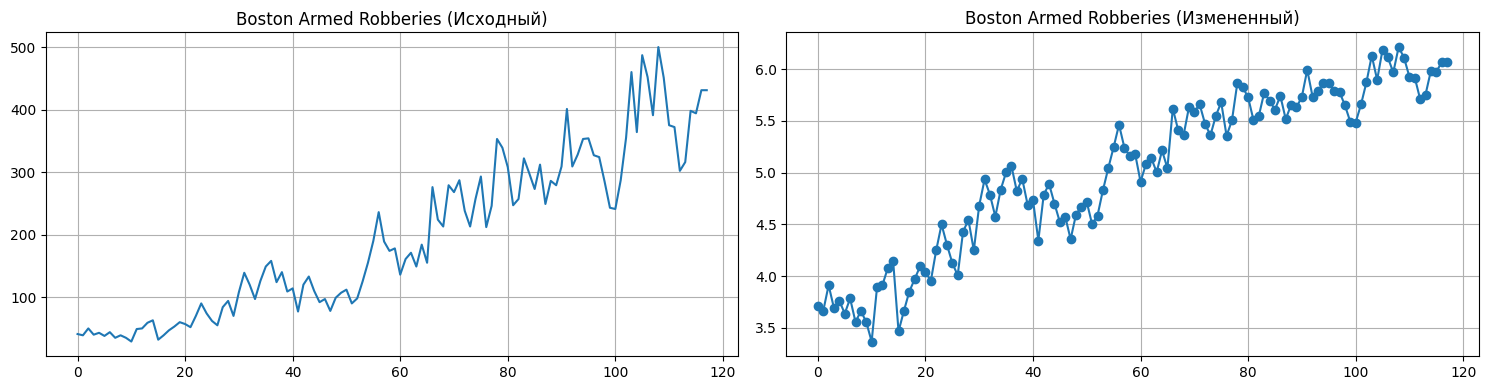

In [61]:
val2_log = np.log(val2)

plot_series(val2, val2_log, title="Boston Armed Robberies")

Построим коррелограмму:

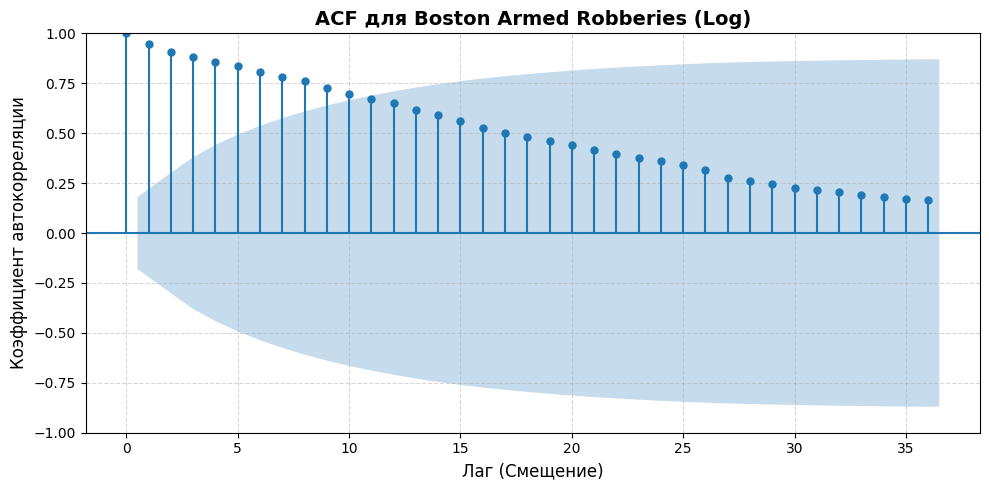

In [83]:
plot_my_acf(val2_log, lags=36, title="ACF для Boston Armed Robberies (Log)")

Ряд имеет сильный возрастающий тренд.

Основываясь на результатах теста Дики-Фуллера найдем оптимальный лаг и проведем дифференцирование:

При лаге деффиринцирования 1 значение p-value минимально


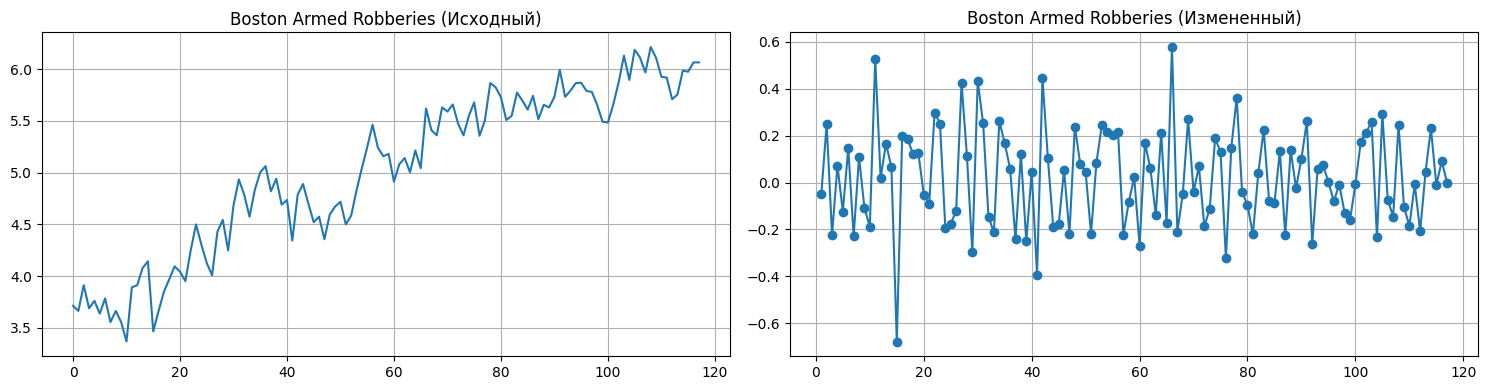

--- Тест Дики-Фуллера для: Boston Armed Robberies ---
Test Statistic                -7.601792e+00
p-value                        2.378602e-11
#Lags Used                     3.000000e+00
Number of Observations Used    1.130000e+02
Critical Value (1%)           -3.489590e+00
Critical Value (5%)           -2.887477e+00
Critical Value (10%)          -2.580604e+00
dtype: float64
Результат: Ряд СТАЦИОНАРЕН (p < 0.05)




In [63]:
best_diff = find_best_diff(val2_log)

if best_diff is None:
    print("Значение не найдено (любое деффиринцирование увеличивает p-value)")
else:
    print(f"При лаге деффиринцирования {best_diff} значение p-value минимально")
    plot_series(val2_log, val2_log.diff(best_diff), title="Boston Armed Robberies")

    test_stationarity_report(val2_log.diff(best_diff), "Boston Armed Robberies")

Визуально в измененном ряде явно выраженной периодичности не наблюдается.

Тест Дики-Фуллера показывает, что мы достигли стационарности.

Выведем коррелограмму:

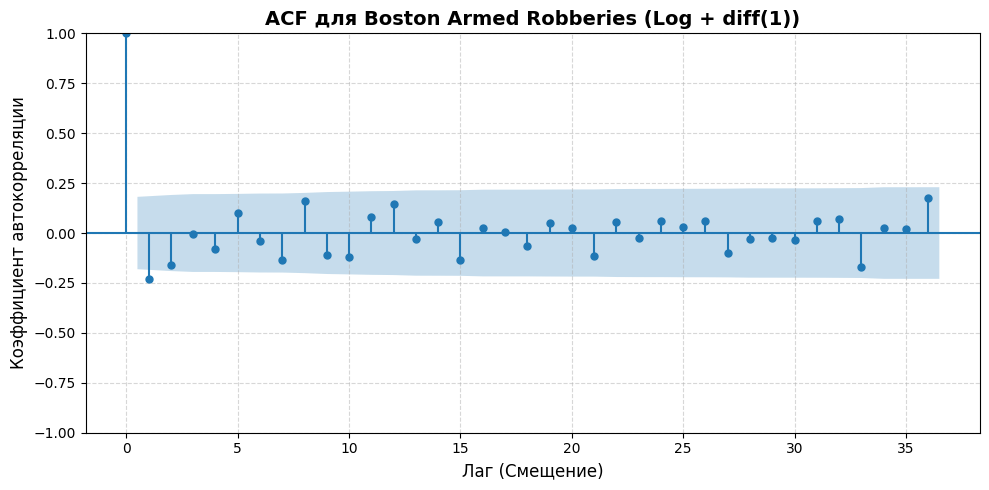

In [84]:
plot_my_acf(val2_log.diff(best_diff), lags=36, title=f"ACF для Boston Armed Robberies (Log + diff({best_diff}))")

## 3. International Airline Passengers

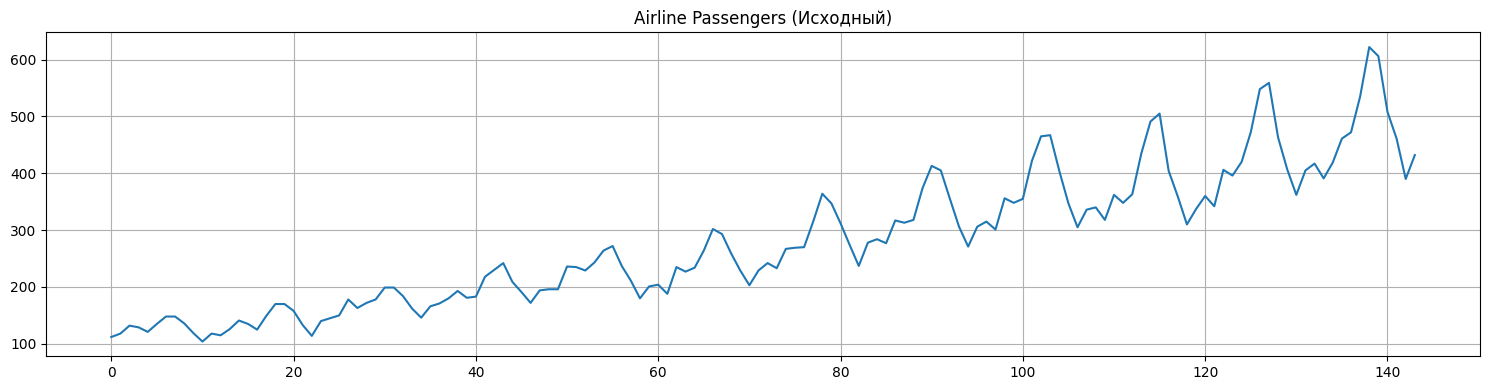

--- Тест Дики-Фуллера для: Airline Passengers ---
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Результат: Ряд НЕСТАЦИОНАРЕН (p >= 0.05)




In [65]:
path3 = 'international-airline-passengers.csv'
df3 = pd.read_csv(path3)
val3 = df3.iloc[:, 1]

plot_series(val3, title="Airline Passengers")

test_stationarity_report(val3, "Airline Passengers")

Заметна увеличивающаяся дисперсия, что выражается в амплитуде колебаний. Для нормализации дисперсии прологарифмируем ряд.

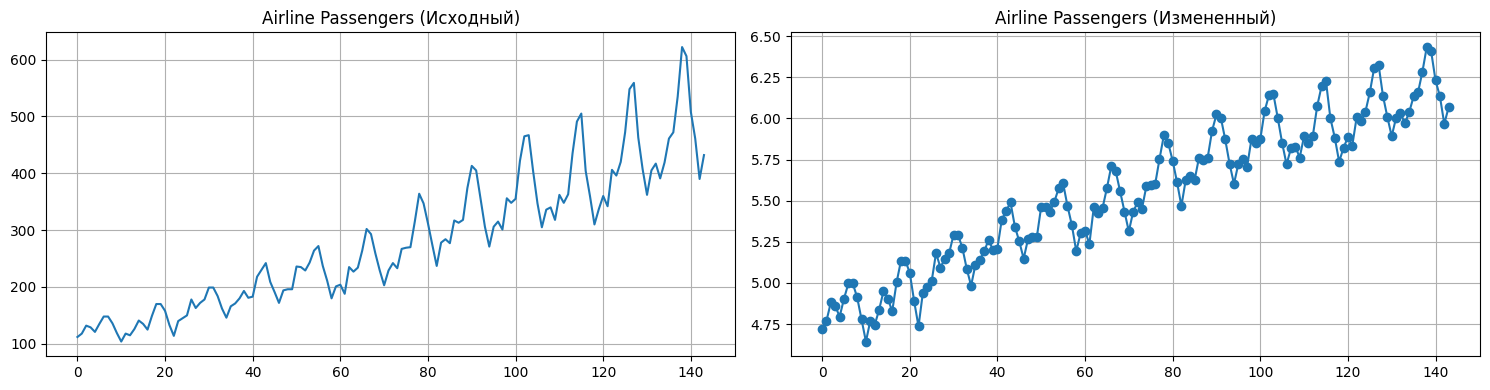

In [66]:
val3_log = np.log(val3)

plot_series(val3, val3_log, title="Airline Passengers")

Построим коррелограмму:

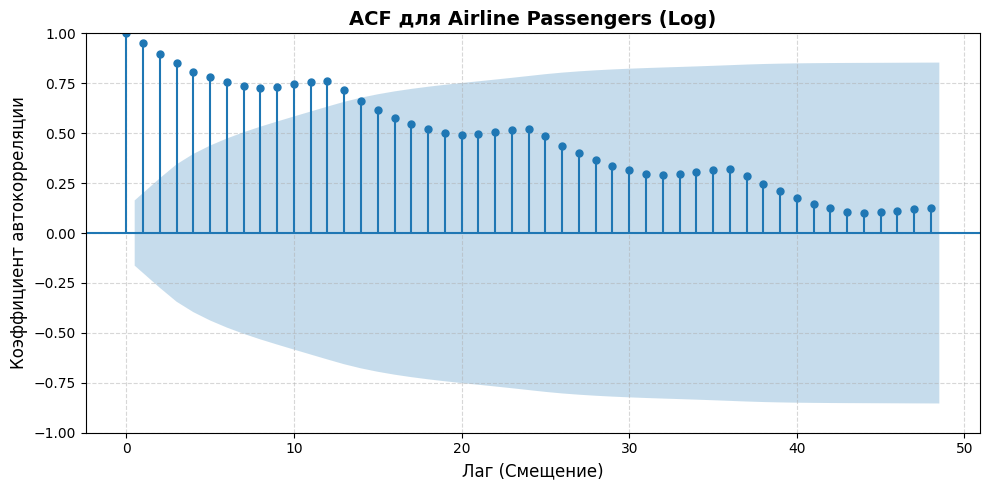

In [85]:
plot_my_acf(val3_log, lags=48, title="ACF для Airline Passengers (Log)")

Хорошо видны пики автокорреляций для смещения кратного 12. Продифференцируем ряд со сдвигом 12:

In [68]:
val3_log_12 = val3_log.diff(12)

Так же ряд имеет сильный возрастающий тренд Проведем дифференцирование:

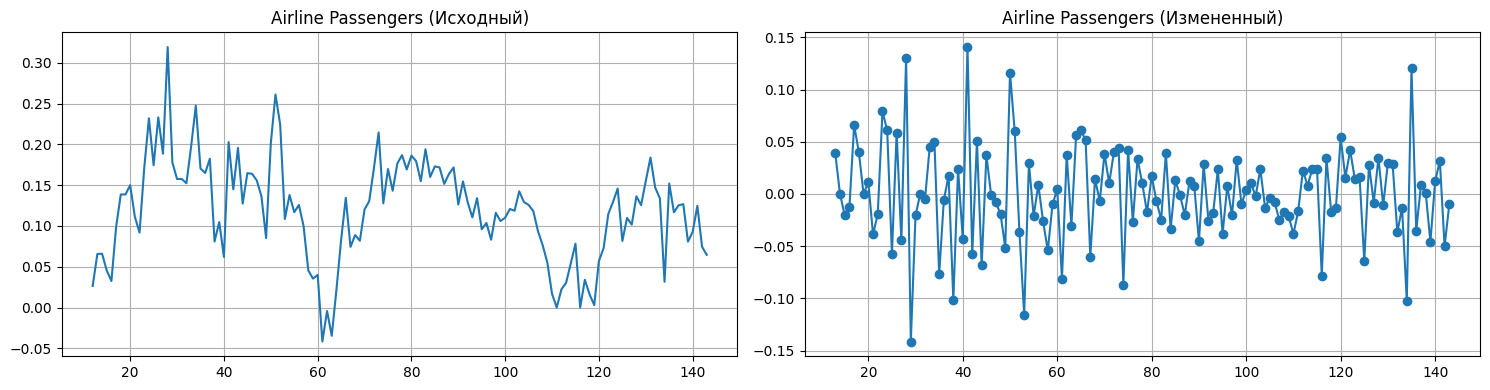

--- Тест Дики-Фуллера для: Airline Passengers ---
Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64
Результат: Ряд СТАЦИОНАРЕН (p < 0.05)




In [69]:
plot_series(val3_log_12, val3_log_12.diff(1), title="Airline Passengers")

test_stationarity_report(val3_log_12.diff(1), "Airline Passengers")

Визуально в измененном ряде явно выраженной периодичности не наблюдается.

Тест Дики-Фуллера показывает, что мы достигли стационарности.

Выведем коррелограмму:

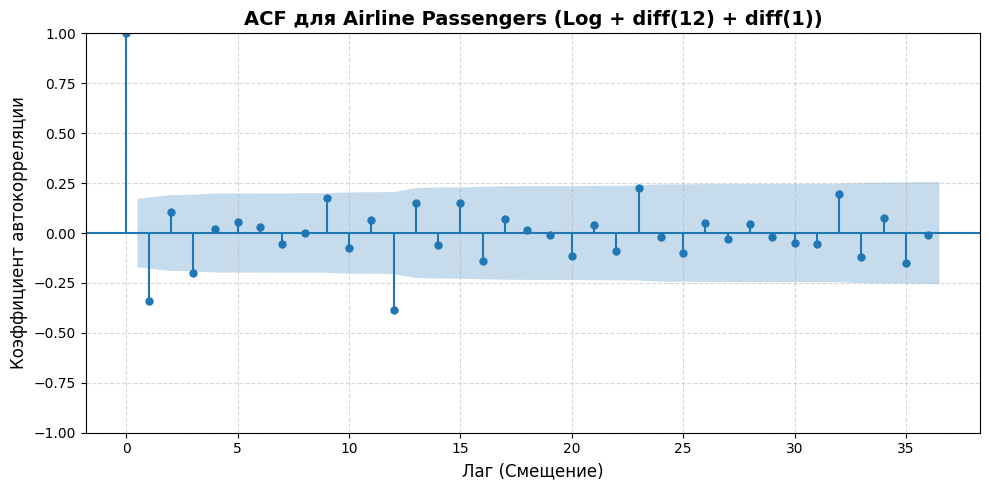

In [70]:
plot_my_acf(val3_log_12.diff(1), lags=36, title=f"ACF для Airline Passengers (Log + diff(12) + diff(1))")

## 4. Mean Monthly Air Temperature

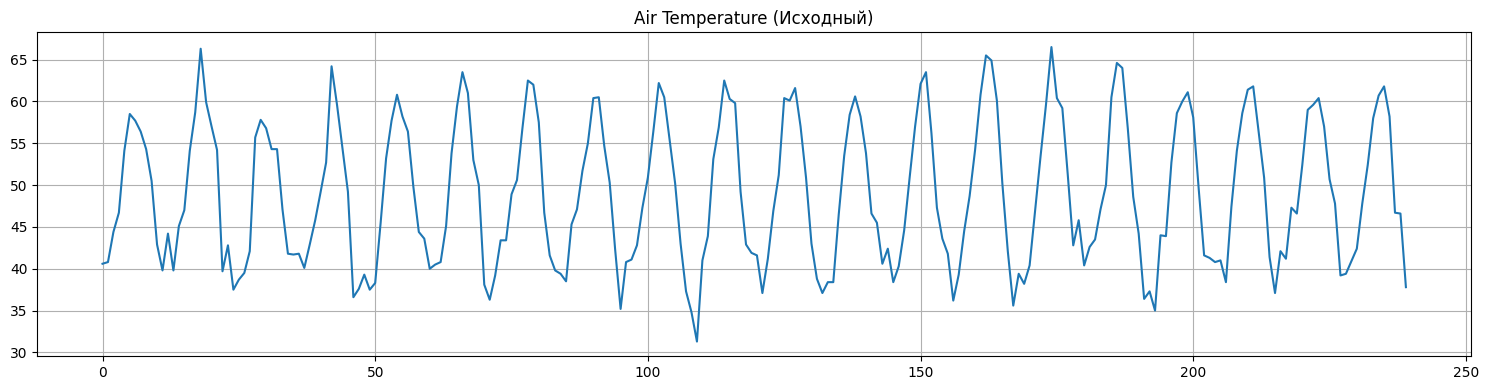

--- Тест Дики-Фуллера для: Air Temperature ---
Test Statistic                  -3.255492
p-value                          0.016989
#Lags Used                      14.000000
Number of Observations Used    225.000000
Critical Value (1%)             -3.459752
Critical Value (5%)             -2.874473
Critical Value (10%)            -2.573663
dtype: float64
Результат: Ряд СТАЦИОНАРЕН (p < 0.05)




In [71]:
path4 = 'mean-monthly-air-temperature-deg.csv'
df4 = pd.read_csv(path4)
val4 = df4.iloc[:, 1]

plot_series(val4, title="Air Temperature")

test_stationarity_report(val4, "Air Temperature")

Визуально наблюдается сезонность, тренд не прослеживается, изменение дисперсии не прослеживается. Построим коррелограмму:

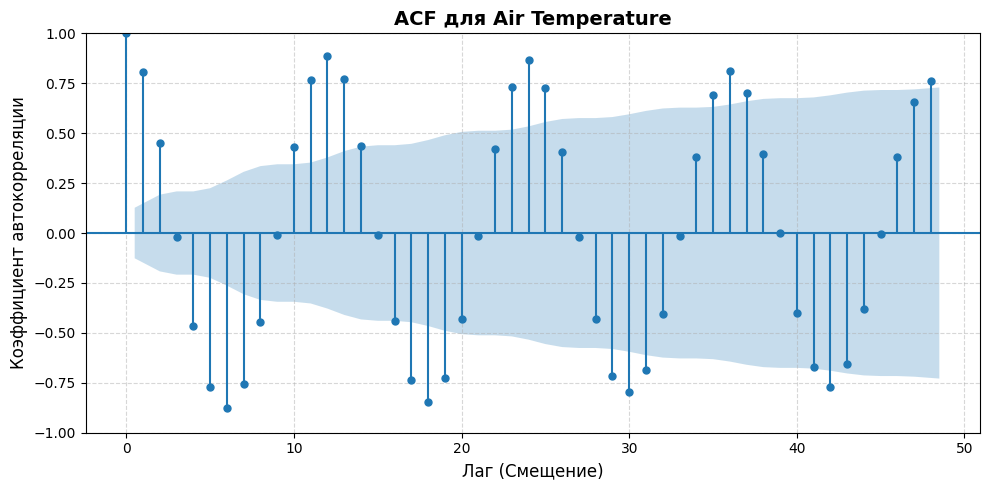

In [72]:
plot_my_acf(val4, lags=48, title="ACF для Air Temperature")

Хорошо видны пики автокорреляций для смещения кратного 12. Продифференцируем ряд со сдвигом 12:

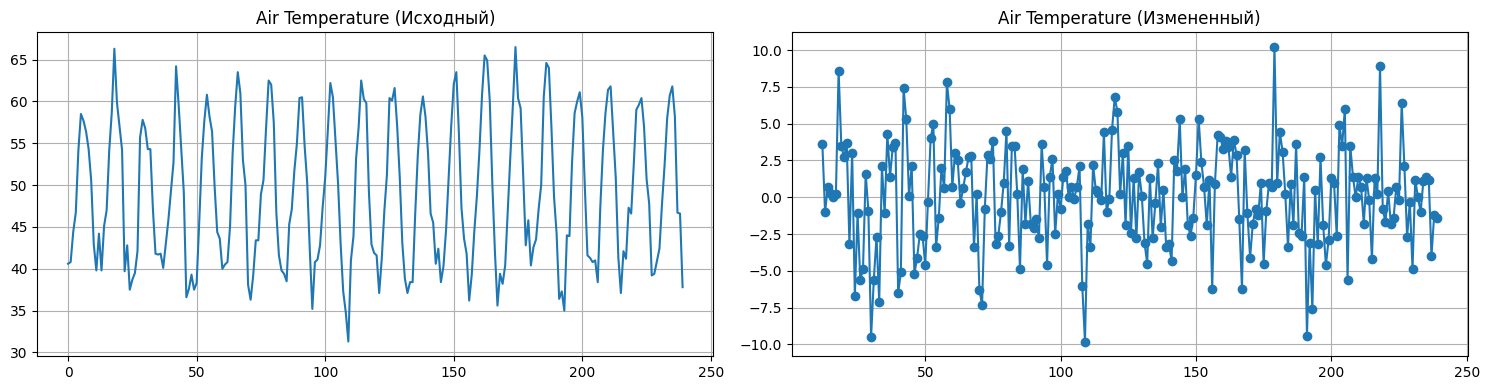

--- Тест Дики-Фуллера для: Air Temperature ---
Test Statistic                -6.072501e+00
p-value                        1.141945e-07
#Lags Used                     1.200000e+01
Number of Observations Used    2.150000e+02
Critical Value (1%)           -3.461136e+00
Critical Value (5%)           -2.875079e+00
Critical Value (10%)          -2.573986e+00
dtype: float64
Результат: Ряд СТАЦИОНАРЕН (p < 0.05)




In [73]:
plot_series(val4, val4.diff(12), title="Air Temperature")

test_stationarity_report(val4.diff(12), "Air Temperature")

Тест Дики-Фуллера показывает, что мы достигли стационарности.

Выведем коррелограмму:

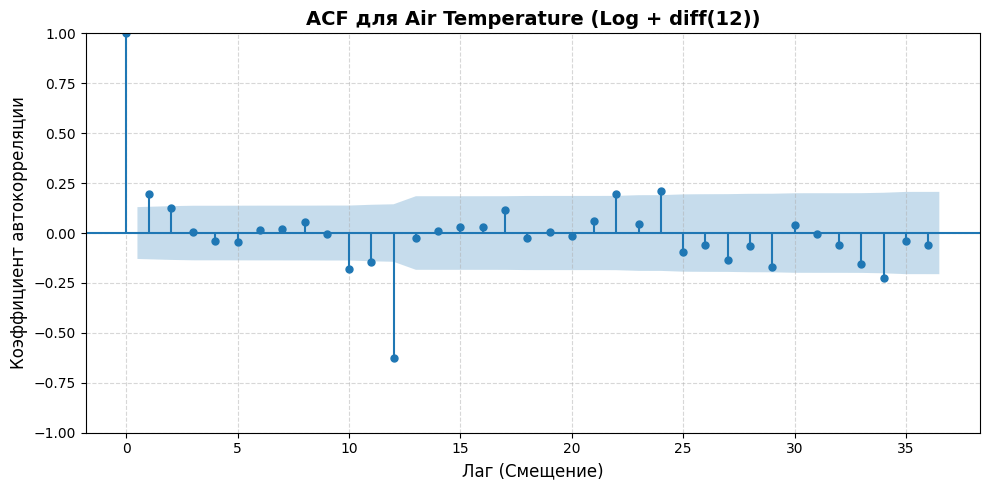

In [74]:
plot_my_acf(val4.diff(12), lags=36, title=f"ACF для Air Temperature (Log + diff(12))")

## 5. Weekly Closings of the Dow Jones

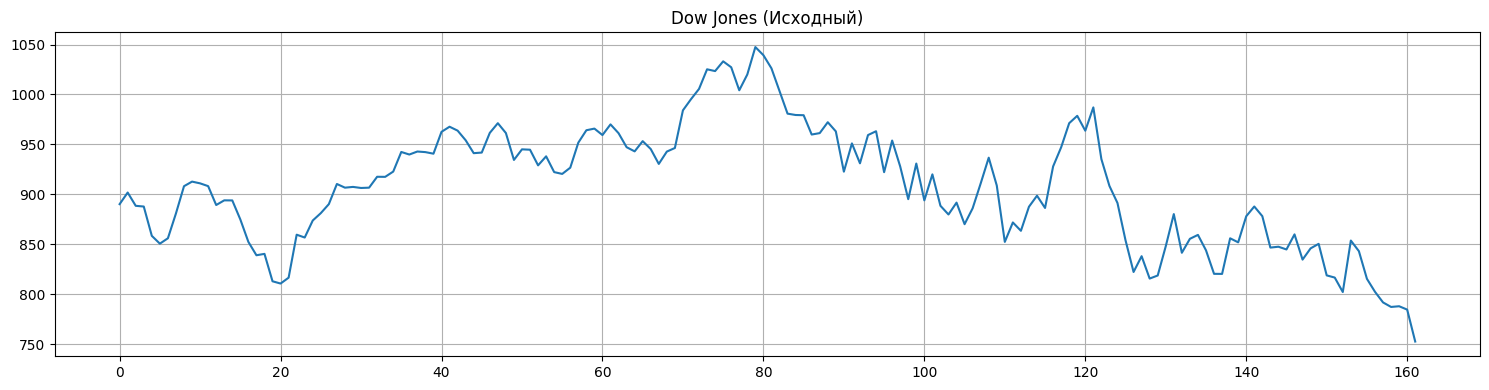

--- Тест Дики-Фуллера для: Dow Jones ---
Test Statistic                  -1.314625
p-value                          0.622455
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64
Результат: Ряд НЕСТАЦИОНАРЕН (p >= 0.05)




In [75]:
path5 = 'weekly-closings-of-the-dowjones-.csv'
df5 = pd.read_csv(path5)
val5 = df5.iloc[:, 1]

plot_series(val5, title="Dow Jones")

test_stationarity_report(val5, "Dow Jones")

Визуально наблюдается случайное блуждание, тренд не прослеживается, изменение дисперсии не прослеживается. Построим коррелограмму:

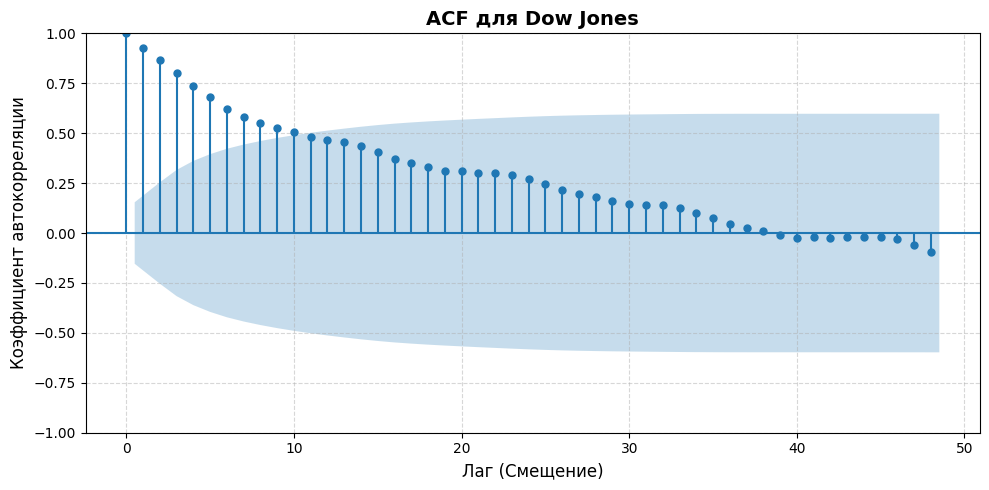

In [76]:
plot_my_acf(val5, lags=48, title="ACF для Dow Jones")

Медленно спадающие значения коррелограммы указывают на наличие тренда.Продифференцируем ряд:

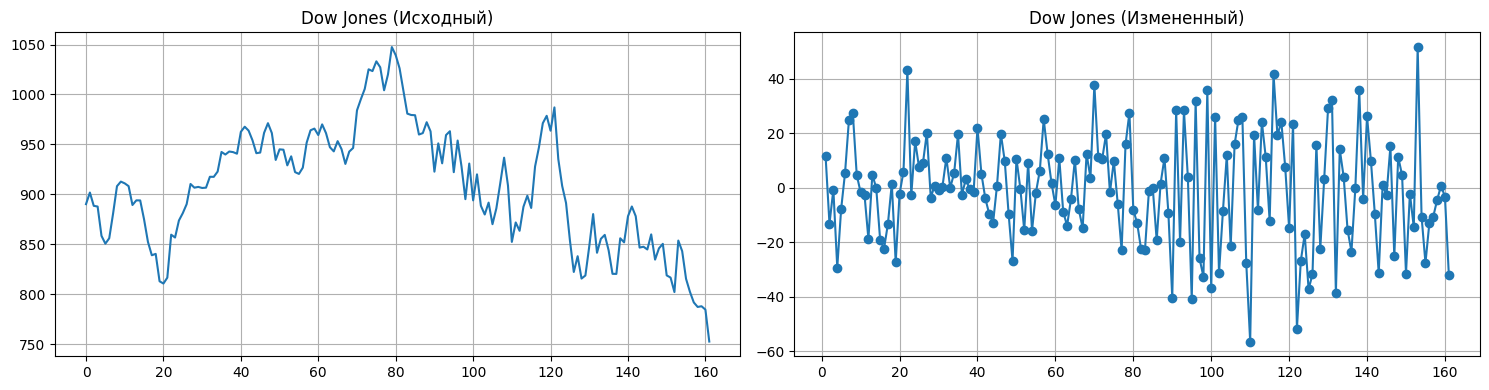

--- Тест Дики-Фуллера для: Dow Jones ---
Test Statistic                -1.302521e+01
p-value                        2.407586e-24
#Lags Used                     0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64
Результат: Ряд СТАЦИОНАРЕН (p < 0.05)




In [77]:
plot_series(val5, val5.diff(1), title="Dow Jones")

test_stationarity_report(val5.diff(1), "Dow Jones")

Тест Дики-Фуллера показывает, что мы достигли стационарности.

Выведем коррелограмму:

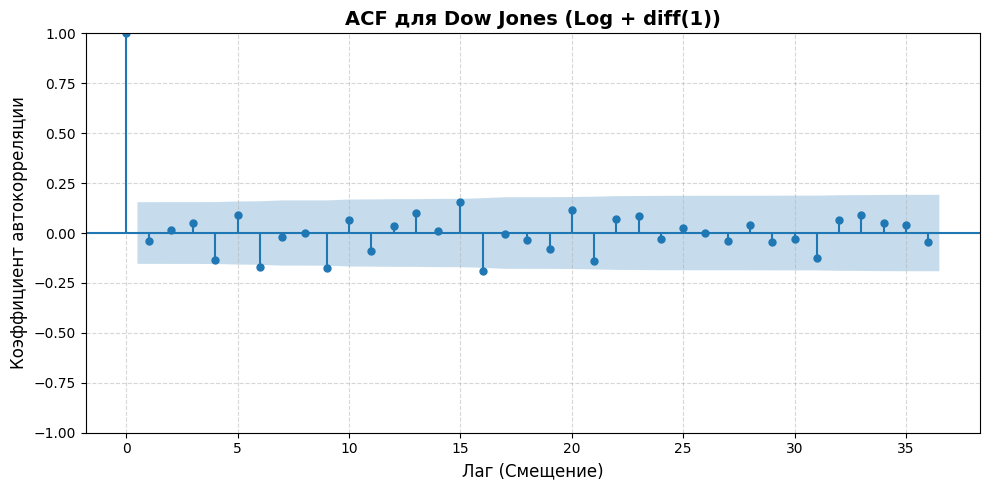

In [78]:
plot_my_acf(val5.diff(1), lags=36, title=f"ACF для Dow Jones (Log + diff(1))")

## 6. Daily Total Female Births in California

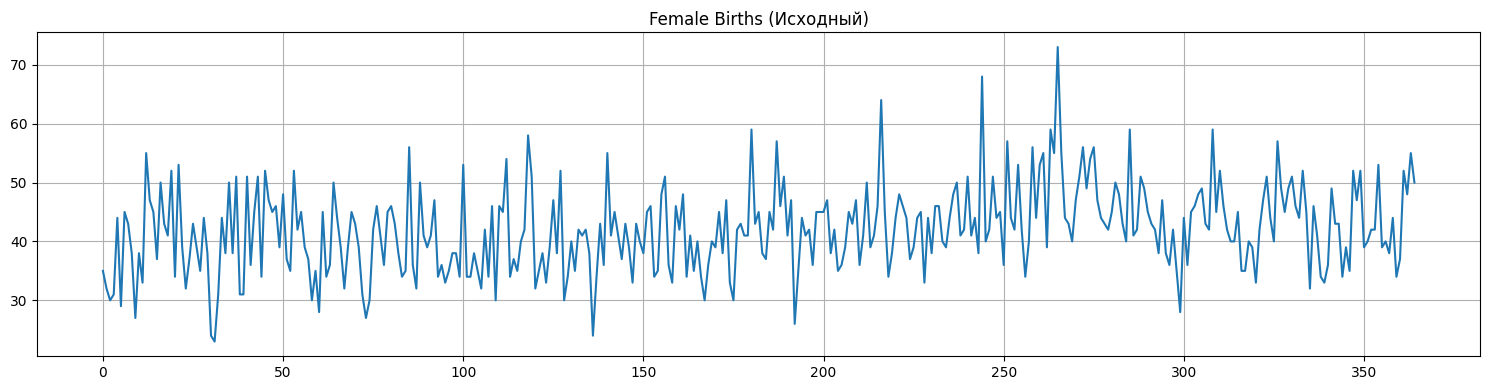

--- Тест Дики-Фуллера для: Female Births ---
Test Statistic                  -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089
dtype: float64
Результат: Ряд СТАЦИОНАРЕН (p < 0.05)




In [80]:
path6 = 'daily-total-female-births-in-cal.csv'
df6 = pd.read_csv(path6)
val6 = df6.iloc[:, 1]

plot_series(val6, title="Female Births")

test_stationarity_report(val6, "Female Births")

Визуально ряд стационарен.

Тест Дики-Фуллера показывает, что ряд стационарности.

Построим коррелограмму:

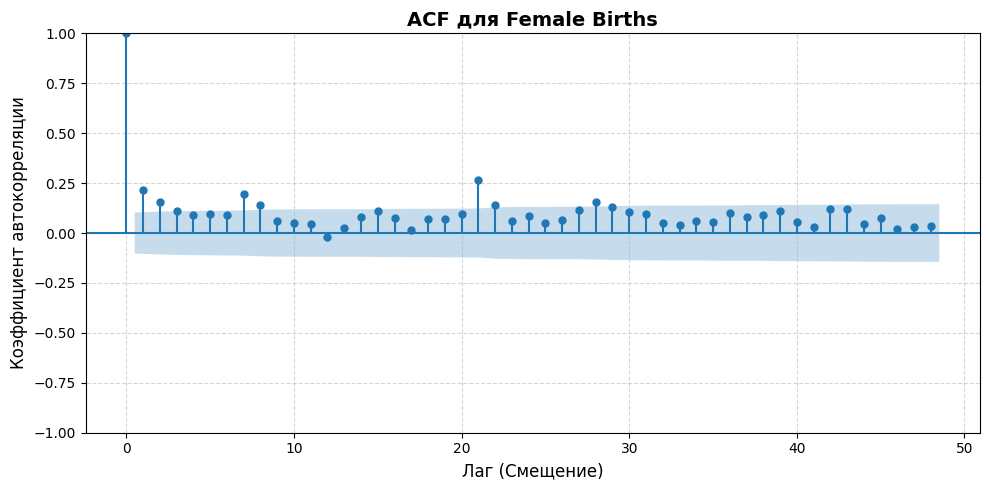

In [81]:
plot_my_acf(val6, lags=48, title="ACF для Female Births")